In [6]:
!pip install openpyxl
!pip install matplotlib
!pip install seaborn
!pip install scipy
!pip install scikit-learn

In [7]:
import pandas as pd
import numpy as np

# four experimental groups
'''
s1: B27	    Ctrl
s2: B27 	MitoMutant
s3: OxlQ	MitoMutant
s4: OxlQ	Ctrl
'''

metadata = pd.DataFrame({
    "sample": ["s1", "s2", "s3", "s4"],
    "medium": ["B27", "B27", "OxIQ", "OxIQ"],
    "mitochondrial_status": [
        "control",
        "mutant",
        "mutant",
        "control"
    ]
})

print("metadata:\n", metadata)


metadata:
   sample medium mitochondrial_status
0     s1    B27              control
1     s2    B27               mutant
2     s3   OxIQ               mutant
3     s4   OxIQ              control


In [ ]:
met_file = "data/SUB16387_metabolomicsData.xlsx"
xls_met = pd.ExcelFile(met_file)

df = pd.read_excel(met_file, sheet_name=xls_met.sheet_names[1], skiprows=7)  # skip the first seven rows, eighth row is the header row
print(xls_met.sheet_names[1])
feature_info = df[["Name", "Formula", "RT [min]"]]



Untargeted data


/Users/safazaidmalik/Documents/MMHP/metabolomics_vis/.venv/lib/python3.13/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Conditional Formatting extension is not supported and will be removed
  warn(msg)


In [5]:
# Abundance matrix for each sample group
abundance = df[["Group Area: B27, Ctrl",
                "Group Area: B27, MitoMutant",
                "Group Area: OxlQ, Ctrl",
                "Group Area: OxlQ, MitoMutant"
            ]]

print(abundance.head(3))

   Group Area: B27, Ctrl  Group Area: B27, MitoMutant  Group Area: OxlQ, Ctrl  \
0           2.328961e+10                 4.720084e+09            1.314689e+10   
1           8.336201e+09                 4.169415e+09            1.923150e+08   
2           4.193670e+09                 1.792087e+09            5.079485e+09   

   Group Area: OxlQ, MitoMutant  
0                  7.216744e+08  
1                  4.829124e+09  
2                  1.844395e+09  


In [6]:
# Check for missing values
missing = abundance.isna().sum()
print("Missing values in abundance data:\n", missing)

# Check for the proportion of missing (NaN) values in each row of df
missing_fraction = abundance.isna().mean(axis=1)
# missing_fraction.describe()

Missing values in abundance data:
 Group Area: B27, Ctrl           0
Group Area: B27, MitoMutant     0
Group Area: OxlQ, Ctrl          0
Group Area: OxlQ, MitoMutant    0
dtype: int64


abundance statistics:
        Group Area: B27, Ctrl  Group Area: B27, MitoMutant  \
count           1.223000e+03                 1.223000e+03   
mean            1.618686e+08                 1.883556e+08   
std             8.715698e+08                 9.930016e+08   
min             1.955417e+04                 4.257171e+04   
25%             4.949736e+06                 3.660458e+06   
50%             1.639474e+07                 1.568341e+07   
75%             6.622501e+07                 5.955571e+07   
max             2.328961e+10                 2.133818e+10   

       Group Area: OxlQ, Ctrl  Group Area: OxlQ, MitoMutant  
count            1.223000e+03                  1.223000e+03  
mean             2.580791e+08                  1.968067e+08  
std              1.309507e+09                  1.052204e+09  
min              3.603527e+04                  2.652163e+04  
25%              1.792753e+06                  3.984209e+06  
50%              1.118878e+07                  1.517854

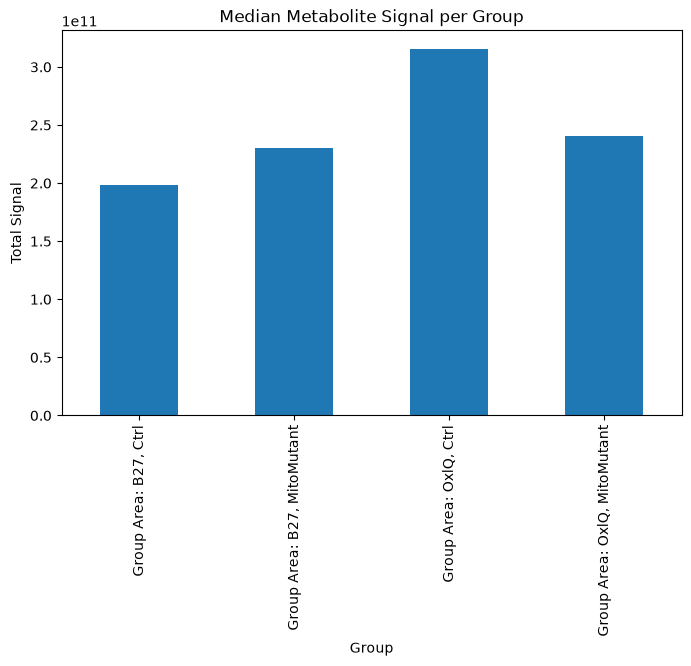

Sample medians (log10):
       Group Area: B27, Ctrl  Group Area: B27, MitoMutant  \
0                 10.367162                     9.673950   
1                  9.920968                     9.620075   
2                  9.622594                     9.253359   
3                  9.863578                     9.794370   
4                  9.843806                     9.776219   
...                     ...                          ...   
1218               4.983031                     5.028893   
1219               4.310231                     4.629121   
1220               4.918368                     5.508087   
1221               5.581705                     5.913028   
1222               5.512817                     5.562458   

      Group Area: OxlQ, Ctrl  Group Area: OxlQ, MitoMutant  
0                  10.118823                      8.858341  
1                   8.284013                      9.683868  
2                   9.705820                      9.265854  
3         

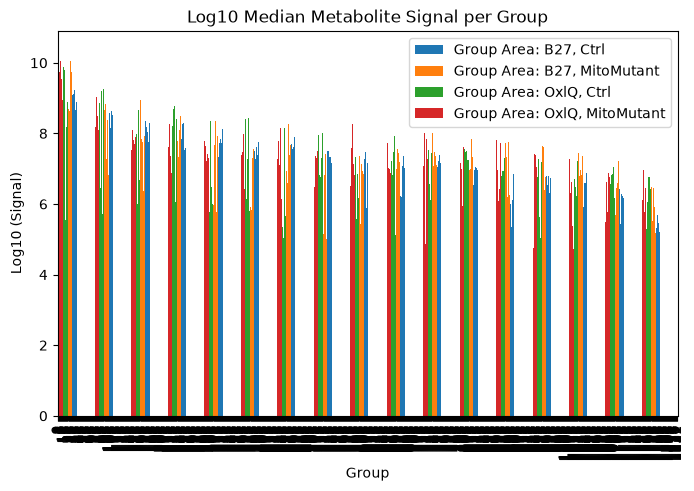

In [7]:
import matplotlib.pyplot as plt
# Examine raw sample intensity
print("abundance statistics:\n", abundance.describe())
print("abundance shape:\n", abundance.shape)

# median signal is already provided in the source data in these columns
sample_medians = abundance.sum(axis=0)
print("Sample medians:\n", sample_medians)
sample_medians.plot(
    kind='bar',
    title='Median Metabolite Signal per Group',
    ylabel='Total Signal',
    xlabel='Group',
    figsize=(8,5)
)
plt.show()

sample_median_log10 = np.log10(abundance)
print("Sample medians (log10):\n", sample_median_log10)
sample_median_log10.plot(
    kind='bar',
    title='Log10 Median Metabolite Signal per Group',
    ylabel='Log10 (Signal)',
    xlabel='Group',
    figsize=(8,5)
)
plt.show()


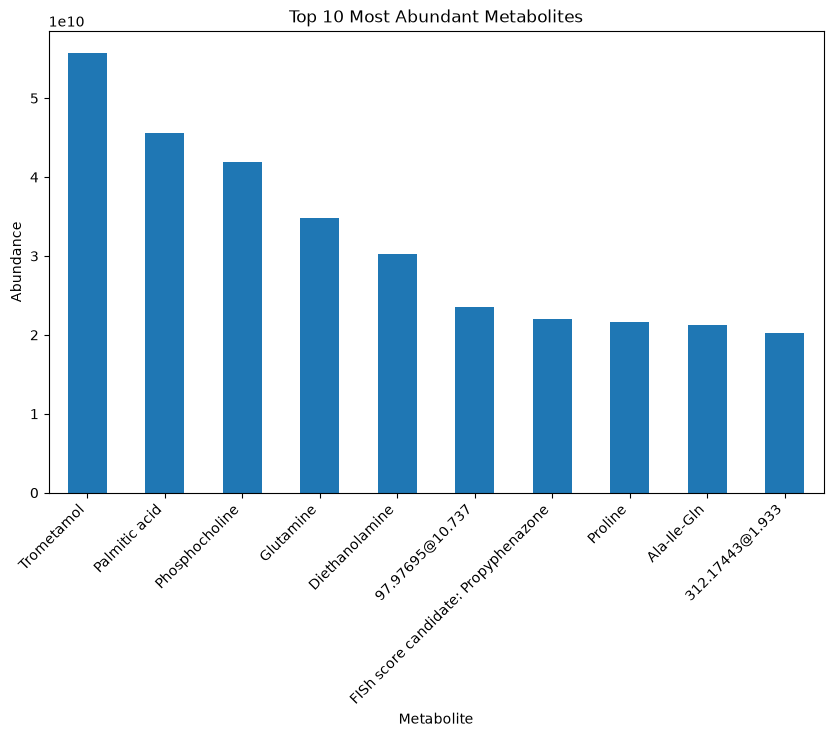

In [8]:
# plot the 10 most abundant metabolites in each group and their abundance distribution across the four groups
top10_metabolites = abundance.sum(axis=1).nlargest(10)
feature_info = df[["Ref", "Name", "Formula", "RT [min]"]]
xticks = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
xvalues = (
    feature_info.loc[top10_metabolites.index, "Name"]
    .fillna(feature_info.loc[top10_metabolites.index, "Ref"])
    .tolist()
)
# xvalues = feature_info.loc[top10_metabolites.index, "Name"].tolist()
# print("xticks:\n", xticks)
# fig, ax = plt.subplots(figsize=(10,6))
# ax.set_xticks(xticks, labels=xvalues, rotation=45, ha='right')
top10_metabolites.plot(kind='bar', title='Top 10 Most Abundant Metabolites', ylabel='Abundance', xlabel='Metabolite', figsize=(10,6))
plt.xticks([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], labels=xvalues, rotation=45, ha='right')
plt.show()

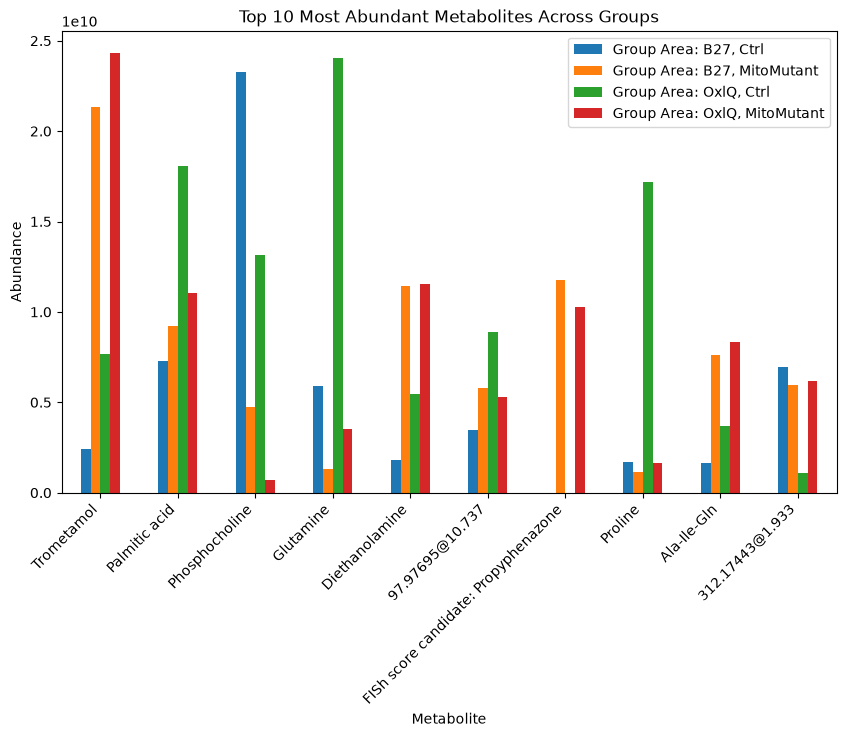

In [9]:
# grouped bar chart to show the abundance of the top 10 metabolites across the four groups
top10_abundance = abundance.loc[top10_metabolites.index]
top10_abundance.plot(kind='bar', title='Top 10 Most Abundant Metabolites Across Groups', ylabel='Abundance', xlabel='Metabolite', figsize=(10,6))
plt.xticks([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], labels=xvalues, rotation=45, ha='right')
plt.show()

raw abundance shape:
 (1223, 8)


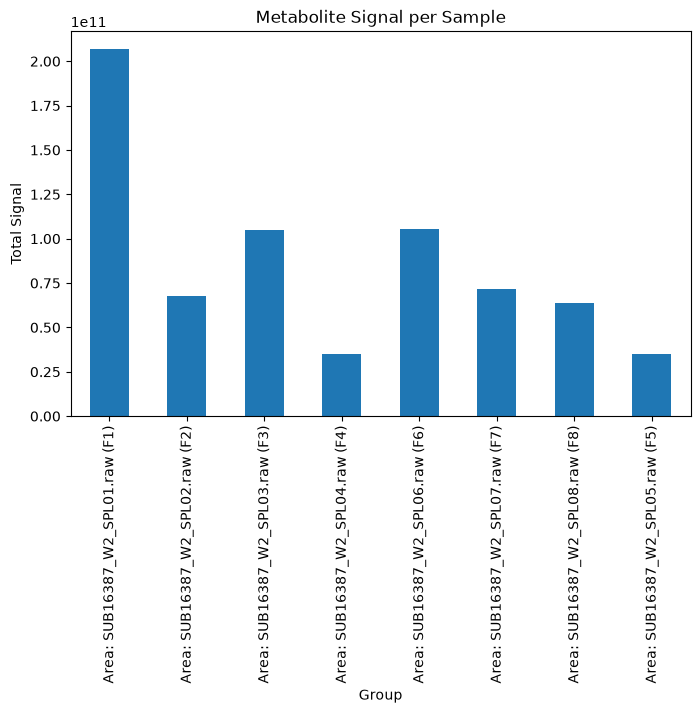

In [10]:
# import matplotlib.pyplot as plt
# Abundance matrix for each sample group
raw_abundance = df[["Area: SUB16387_W2_SPL01.raw (F1)",
                "Area: SUB16387_W2_SPL02.raw (F2)",
                "Area: SUB16387_W2_SPL03.raw (F3)",
                "Area: SUB16387_W2_SPL04.raw (F4)",
                "Area: SUB16387_W2_SPL06.raw (F6)",
                "Area: SUB16387_W2_SPL07.raw (F7)",
                "Area: SUB16387_W2_SPL08.raw (F8)",
                "Area: SUB16387_W2_SPL05.raw (F5)"
            ]]

# print(raw_abundance.head(3))

# Examine raw sample intensity
# print("raw abundance statistics:\n", raw_abundance.describe())
print("raw abundance shape:\n", raw_abundance.shape)

# median signal is already provided in the source data in these columns
sample = raw_abundance.sum(axis=0)
# print("Sample totals:\n", sample)
sample.plot(
    kind='bar',
    title='Metabolite Signal per Sample',
    ylabel='Total Signal',
    xlabel='Group',
    figsize=(8,5)
)
plt.show()

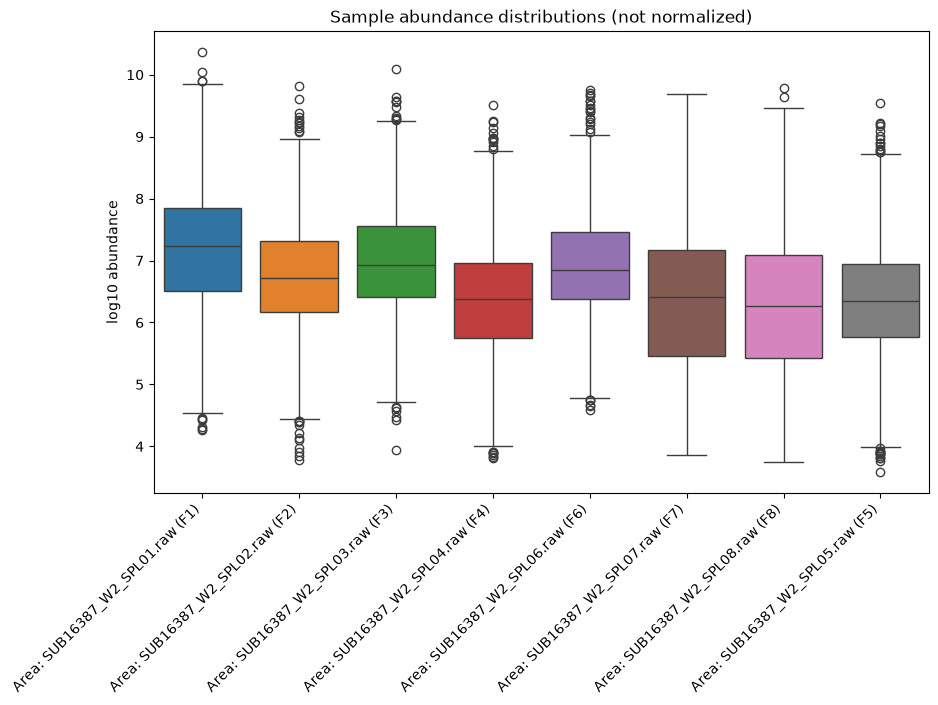

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

# Log transform raw abundance data
log_abundance = np.log10(raw_abundance + 1) # Adding 1 to avoid log(0)

plt.figure(figsize=(10,6))
# for sample in log_abundance.columns:
#     sns.kdeplot(log_abundance[sample], label=sample)
# plt.title('Density Plot of Log2 Transformed Abundance Data')
# plt.xlabel('Log2 Abundance')
# plt.ylabel('Density')
# plt.legend()
# plt.show()

sns.boxplot(data=log_abundance)

plt.ylabel("log10 abundance")
plt.title("Sample abundance distributions (not normalized)")
plt.xticks([0,1,2,3,4,5,6,7], labels=log_abundance.columns, rotation=45, ha='right')
plt.show()

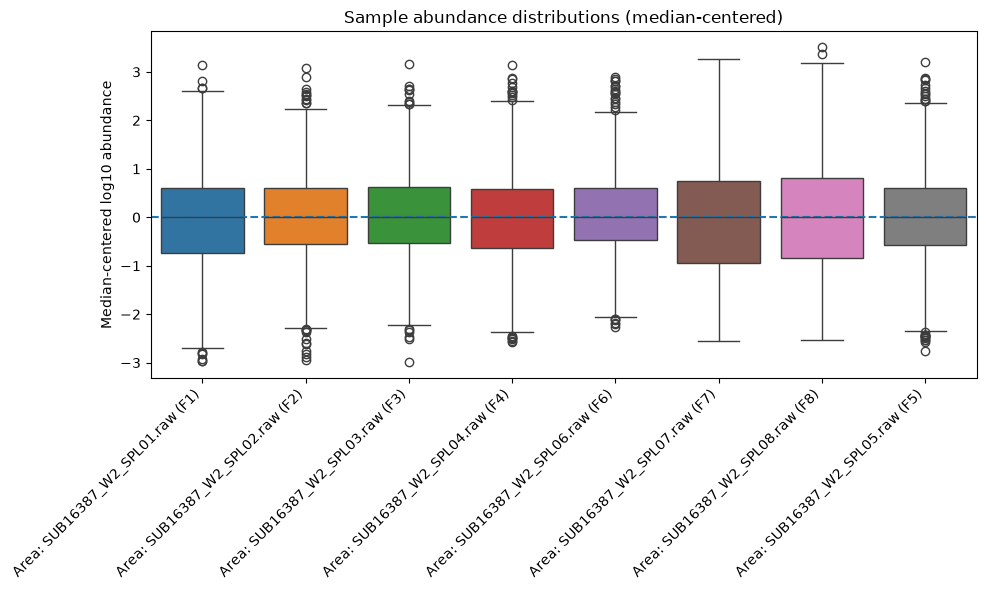

In [12]:
# Median centerd boxplots
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Log transform
log_abundance = np.log10(raw_abundance + 1)

# For each sample column, calculate the median across all metabolites:
sample_medians = log_abundance.median(axis=0)
# Then median-center each sample
median_centered = log_abundance.subtract(sample_medians, axis=1)

median_centered.median(axis=0)

# Median-center each sample
# median_centered = log_abundance.subtract(
#     log_abundance.median(axis=0),
#     axis=1
# )

# Plot
plt.figure(figsize=(10, 6))

sns.boxplot(data=median_centered)

plt.ylabel("Median-centered log10 abundance")
plt.title("Sample abundance distributions (median-centered)")
plt.xticks(
    range(len(median_centered.columns)),
    median_centered.columns,
    rotation=45,
    ha='right'
)
plt.axhline(0, linestyle='--')
plt.tight_layout()
plt.show()

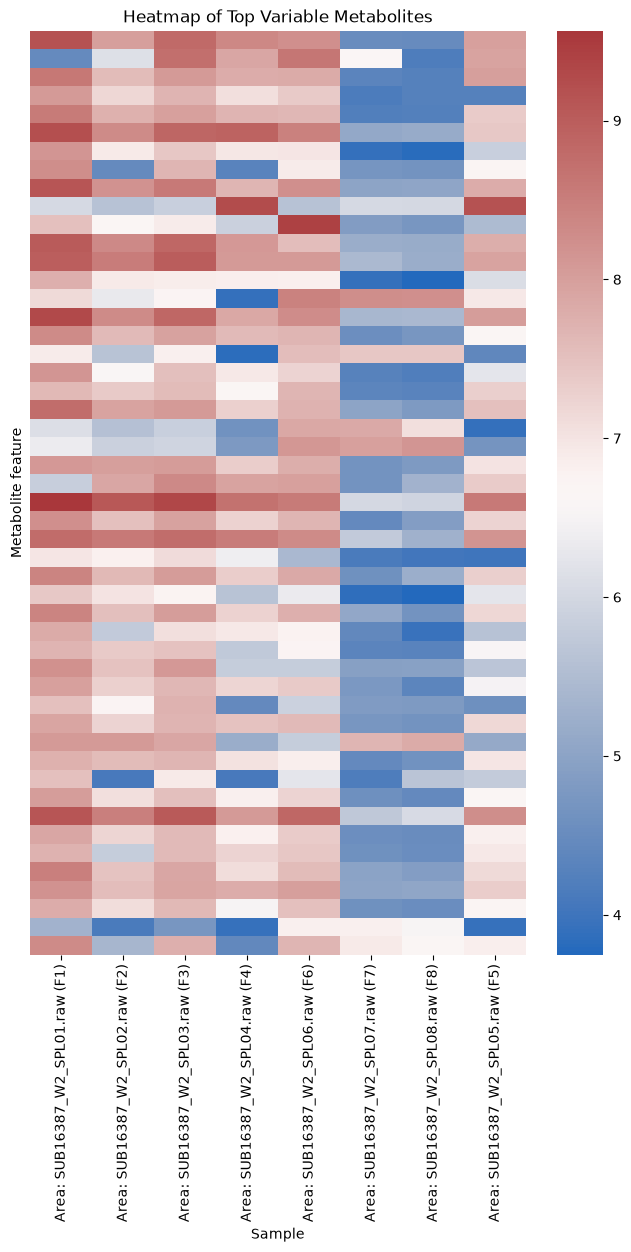

In [13]:
# Heatmap to show the most variable metabolites across the four groups
feature_variance = log_abundance.var(axis=1)
top_features = feature_variance.nlargest(50).index
heatmap_data = log_abundance.loc[top_features]

plt.figure(figsize=(8, 12))
sns.heatmap(heatmap_data, cmap='vlag', xticklabels=True, yticklabels=False)
plt.title("Heatmap of Top Variable Metabolites")
plt.xlabel("Sample")
plt.ylabel("Metabolite feature")
plt.show()

In [26]:
groups = {
    "F1": "B27 Ctrl",
    "F2": "B27 Ctrl",
    "F3": "B27 Ctrl",
    "F4": "B27 MitoMutant",
    "F5": "OxIQ MitoMutant",
    "F6": "OxIQ Ctrl",
    "F7": "OxIQ Ctrl",
    "F8": "OxIQ Ctrl"
}

# Extract F1, F2, etc. from the column names
sample_ids = heatmap_data.columns.str.extract(r"\((F\d+)\)$", expand=False)

# Assign each sample to its group, preserving the original column order
group_labels = pd.Series(sample_ids.to_numpy(), index=heatmap_data.columns).map(groups)

# Map groups to colors
color_map = {
    "B27 Ctrl": "blue",
    "B27 MitoMutant": "orange",
    "OxIQ Ctrl": "green",
    "OxIQ MitoMutant": "red"
}

col_colors = group_labels.map(color_map)

# Check that every sample has a group and color
print(group_labels)
print(col_colors)

Area: SUB16387_W2_SPL01.raw (F1)           B27 Ctrl
Area: SUB16387_W2_SPL02.raw (F2)           B27 Ctrl
Area: SUB16387_W2_SPL03.raw (F3)           B27 Ctrl
Area: SUB16387_W2_SPL04.raw (F4)     B27 MitoMutant
Area: SUB16387_W2_SPL06.raw (F6)          OxIQ Ctrl
Area: SUB16387_W2_SPL07.raw (F7)          OxIQ Ctrl
Area: SUB16387_W2_SPL08.raw (F8)          OxIQ Ctrl
Area: SUB16387_W2_SPL05.raw (F5)    OxIQ MitoMutant
dtype: str
Area: SUB16387_W2_SPL01.raw (F1)      blue
Area: SUB16387_W2_SPL02.raw (F2)      blue
Area: SUB16387_W2_SPL03.raw (F3)      blue
Area: SUB16387_W2_SPL04.raw (F4)    orange
Area: SUB16387_W2_SPL06.raw (F6)     green
Area: SUB16387_W2_SPL07.raw (F7)     green
Area: SUB16387_W2_SPL08.raw (F8)     green
Area: SUB16387_W2_SPL05.raw (F5)       red
dtype: str


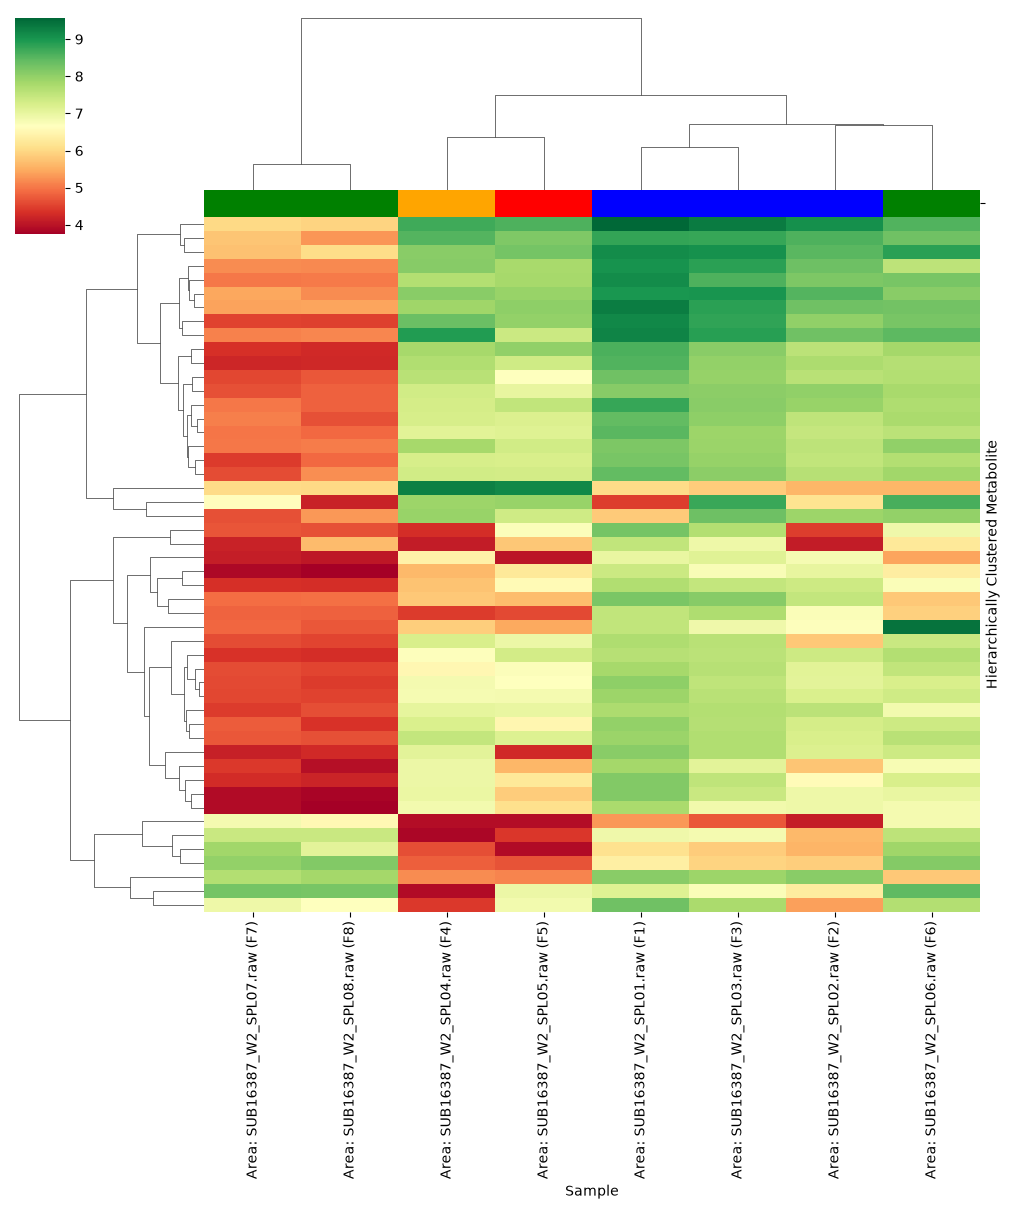

In [29]:
import scipy

# groups = {
#     "F1": "B27 Ctrl",
#     "F2": "B27 Ctrl",
#     "F3": "B27 Ctrl",
#     "F4": "B27 MitoMutant",
#     "F5": "OxIQ MitoMutant",
#     "F6": "OxIQ Ctrl",
#     "F7": "OxIQ Ctrl",
#     "F8": "OxIQ Ctrl"
# }

# group_labels = heatmap_data.columns.map(groups)

# if group_labels.isna().any():
#     print("Missing group assignments for:")
#     print(heatmap_data.columns[group_labels.isna()].tolist())


g = sns.clustermap(
    heatmap_data,
    method="complete",
    metric="Euclidean",
    row_cluster=True,
    col_cluster=True,
    cmap='RdYlGn',
    col_colors=col_colors,
    xticklabels=True,
    yticklabels=False,
    figsize=(10, 12)
)
# g.ax_heatmap.set_title("Hierarchical Clustering of Top Variable Metabolites")
g.ax_heatmap.set_xlabel("Sample")
g.ax_heatmap.set_ylabel("Hierarchically Clustered Metabolite")
plt.show()

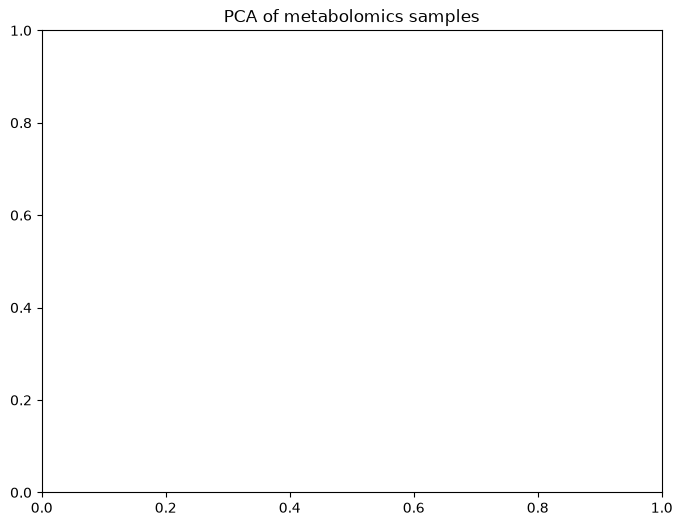

In [34]:
# PCA plot 
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

X = log_abundance.T

X_scaled = StandardScaler().fit_transform(X)

pca = PCA(n_components=2)

principal_components = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(
    principal_components,
    columns=["PC1", "PC2"],
    index=X.index
)

# pca_df
sample_groups = {
    "s1": "B27 control",
    "s2": "B27 mito mutant",
    "s3": "OxIQ mito mutant",
    "s4": "OxIQ control"
}
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue=pca_df.index.map(sample_groups),
    s=150
)

plt.title("PCA of metabolomics samples")
plt.show()